# KDUQ corpus: proton reaction

The KDUQ corpus is a reconstruction of the experimental data used in the Koning-Delaroche global optical potential analysis, assembled from EXFOR by the supplement's authors and tabulated in Supplemental Material B.

Proton reaction (nonelastic) cross sections, in barns against incident lab energy.

The subentries and scattering energies below are transcribed from the supplement's
tables into `spec/kduq_proton_reaction.csv`. Every row must be accounted for: it either
produces data, or it is listed in `spec/known_missing.csv` with a reason. Uncertainties
are assigned by the supplement's preference rule (`nn_corpora.errors`), and the
corrections its Comments describe are applied from `nn_corpora.overrides`.

In [1]:
%matplotlib inline
import matplotlib
from matplotlib import pyplot as plt

import pandas as pd

from nn_corpora import corpus, plotting, report, spec

pd.set_option("display.max_rows", 200)

Using database version X4-2025-12-31 located in: /mnt/home/beyerkyl/x4db/unpack_exfor-2025/X4-2025-12-31


## The specification

In [2]:
rows = spec.load_sector('kduq', 'proton_reaction')
print(f"{len(rows)} rows, {len({r.subentry for r in rows if r.in_exfor})} distinct subentries")
pd.DataFrame([vars(r) for r in rows]).head(15)

89 rows, 84 distinct subentries


,corpus,sector,projectile,target_A,target_Z,target_label,energy_mev,energy_hi_mev,subentry,pointer,pdf_page
0,kduq,proton_reaction,proton,27,13,27Al,8.87,10.39,D0314002,,18
1,kduq,proton_reaction,proton,27,13,27Al,8.80,NaN,D0535002,,18
2,kduq,proton_reaction,proton,27,13,27Al,9.89,NaN,C1042003,,18
3,kduq,proton_reaction,proton,27,13,27Al,9.90,10.12,O0741004,,18
4,kduq,proton_reaction,proton,27,13,27Al,16.29,NaN,O0368004,,18
5,kduq,proton_reaction,proton,27,13,27Al,24.80,46.30,O0325003,,18
6,kduq,proton_reaction,proton,27,13,27Al,29.00,NaN,O0369003,,18
7,kduq,proton_reaction,proton,27,13,27Al,34.00,NaN,O0732003,,18
8,kduq,proton_reaction,proton,27,13,27Al,40.00,60.80,O0081008,,18
9,kduq,proton_reaction,proton,27,13,27Al,61.00,NaN,O0475003,,18


## Retrieve and clean

`corpus.curate` retrieves each entry, matches measurements back to the rows that asked
for them, applies the documented corrections, and homogenises units and frames.

In [3]:
result = corpus.curate('kduq', 'proton_reaction')
print(result.summary())

kduq/proton_reaction
  spec rows              89
  ... marked absent      5
  ... resolved           62 / 84 (73.8%)
  measurements           62
  data points            204
  EXFOR entries          23
  unresolved by category
    x4i3-parse-failure       19
    absent-from-exfor        5
    subentry-withdrawn       3
  serialized             62 measurements, 204 points


## Rows that did not resolve

Every row listed here must appear in `spec/known_missing.csv`, or the write below will
fail. The categories are: `absent-from-exfor` (the supplement itself marks the row as
not locatable), `x4i3-parse-failure` (the entry is in EXFOR but x4i3 cannot read it),
`subentry-withdrawn` (EXFOR has renumbered or removed the subentry since the supplement
was written), `energy-not-found`, and `uncertainty-unresolved`.

In [4]:
print(report.unresolved_table(result.data))

27Al    185.000           [absent-from-exfor] the supplement marks this row as absent from EXFOR
63Cu      6.750           [absent-from-exfor] the supplement marks this row as absent from EXFOR
63Cu      9.850           [absent-from-exfor] the supplement marks this row as absent from EXFOR
natCu   185.000           [absent-from-exfor] the supplement marks this row as absent from EXFOR
natPb   185.000           [absent-from-exfor] the supplement marks this row as absent from EXFOR
27Al      9.890 C1042003  [subentry-withdrawn] subentry not present in entry C1042 for this quantity
natFe     9.890 C1042006  [subentry-withdrawn] subentry not present in entry C1042 for this quantity
63Cu      9.890 C1042009  [subentry-withdrawn] subentry not present in entry C1042 for this quantity
40Ca     28.500 O0150002  [x4i3-parse-failure] uncertainty unresolved (entry-unavailable): entry O0150 is not in the x4i3 index; it is most likely one of the entries x4i3 fails to parse
56Fe     28.500 O0150003  

## Uncertainty audit

Data sets with missing uncertainties are dropped during munging, following the
supplement's removal of any data set lacking a necessary feature. This lists anything
that survived but still looks suspicious.

In [5]:
flags = plotting.check_uncertainties(result)
print("\n".join(flags) if flags else "every measurement carries uncertainties")

every measurement carries uncertainties


## Inspect

Outliers here are found by eye. A mistranscribed point shows up as a single datum an
order of magnitude away from its neighbours; a badly normalised data set shows up as a
whole curve offset from others at the same energy.

... 6 further targets not plotted


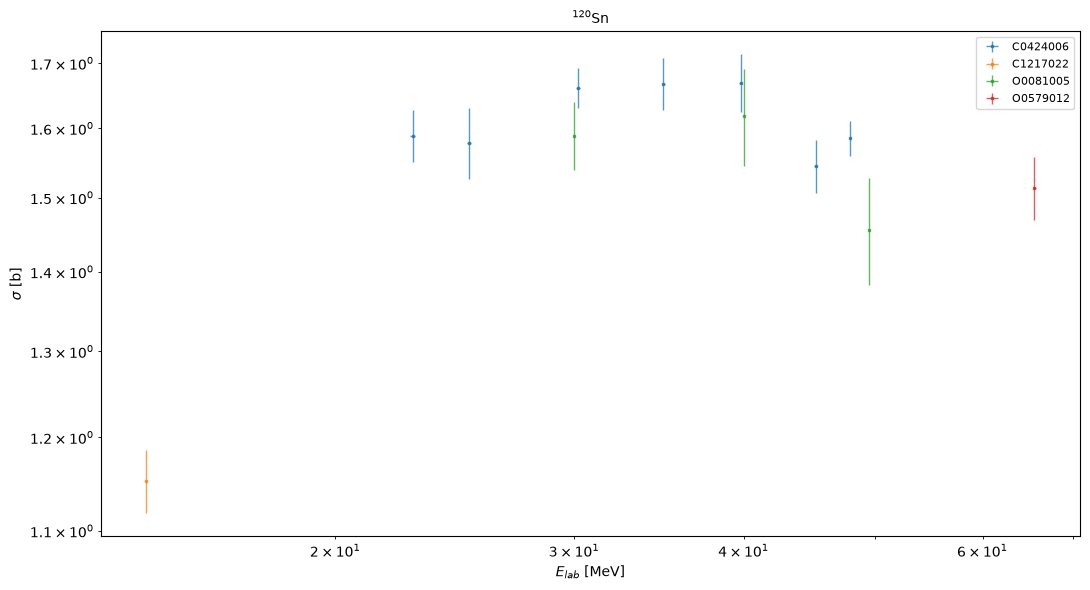

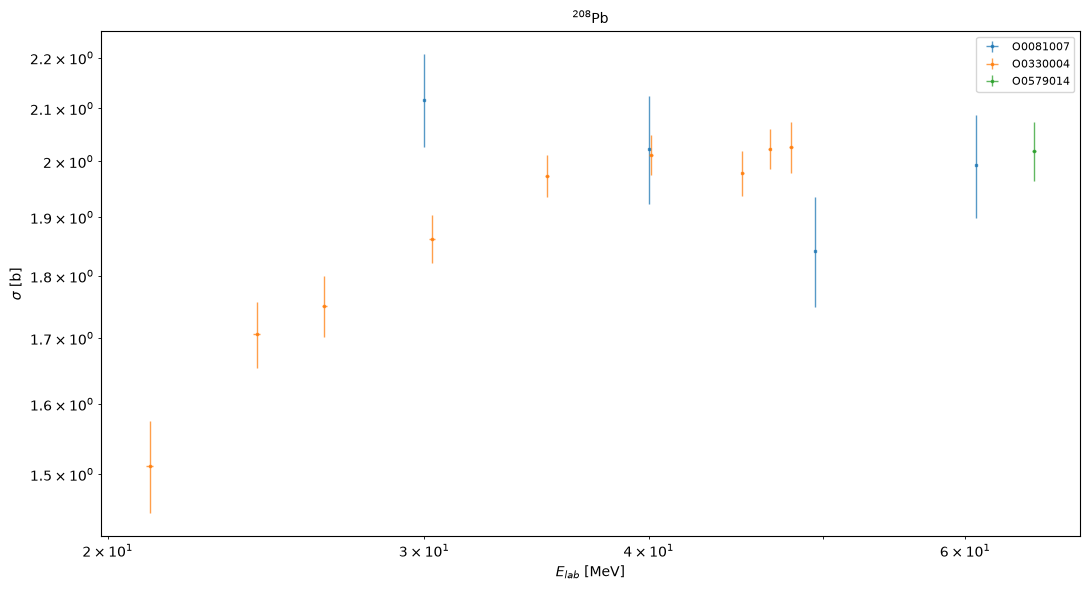

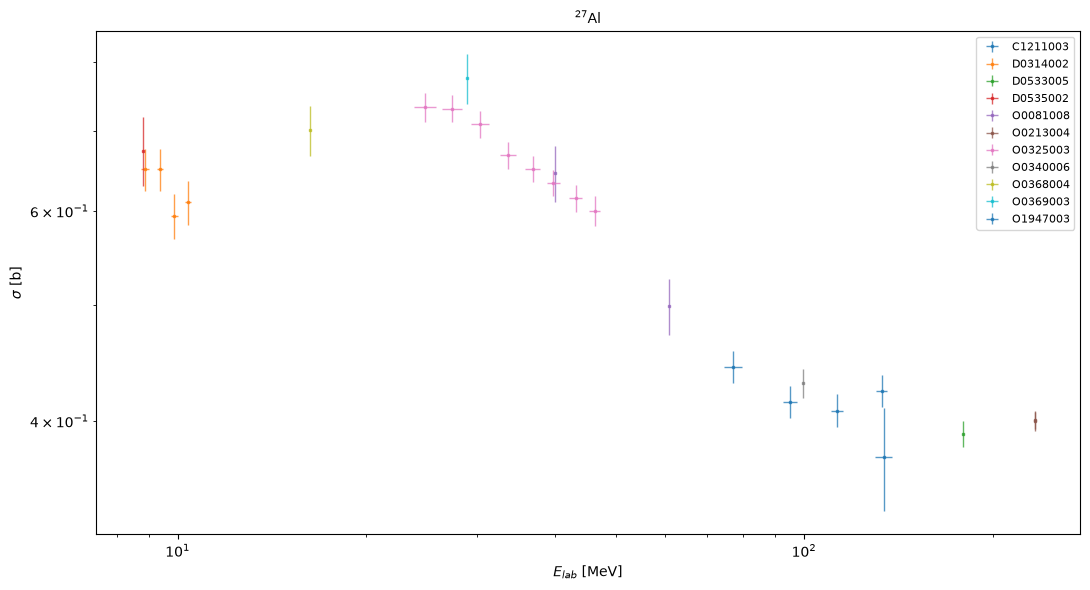

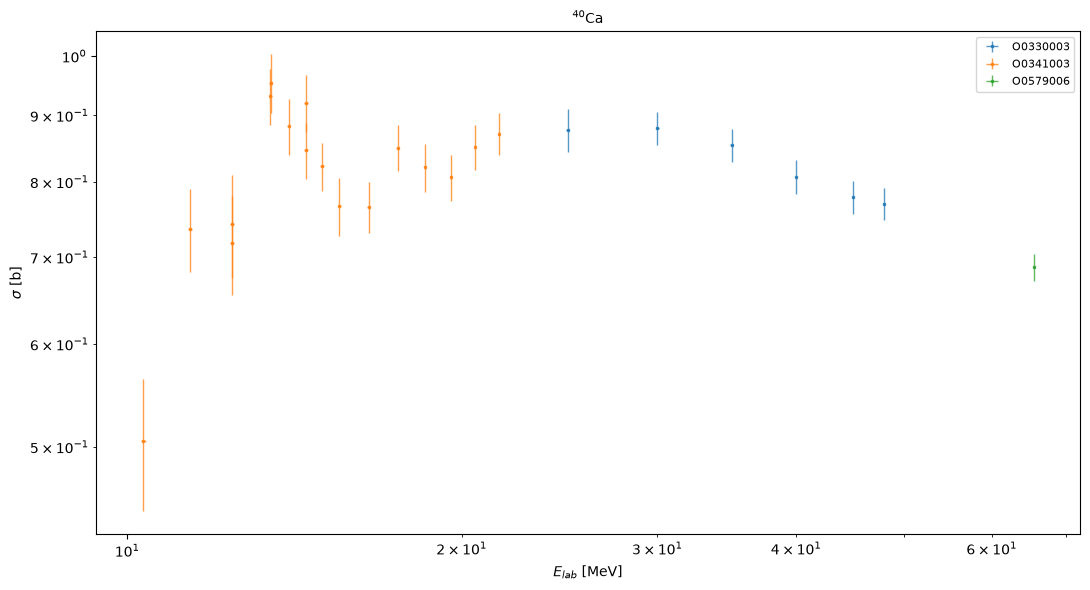

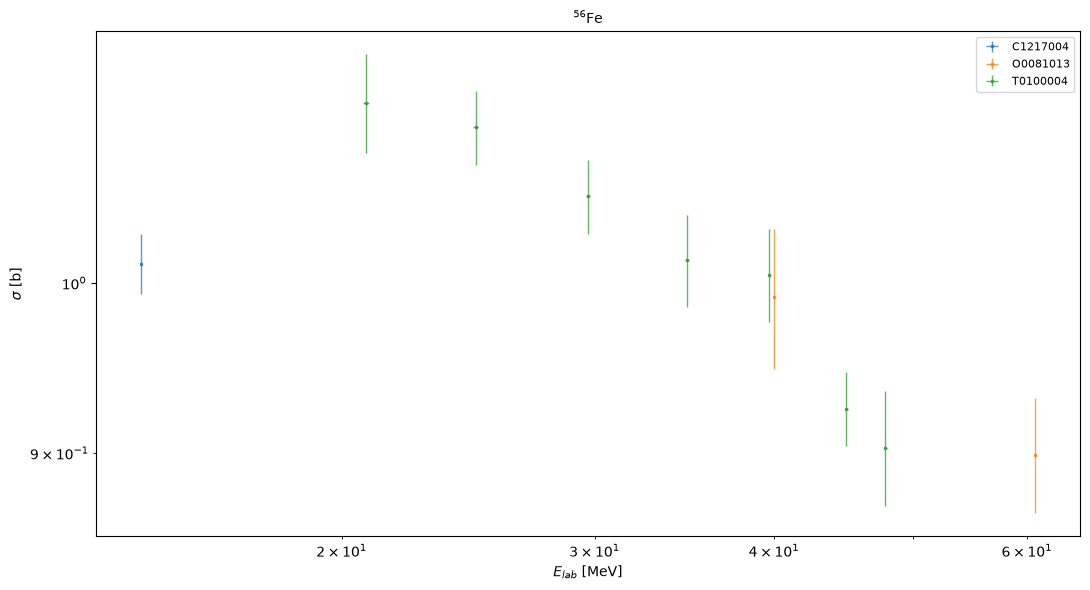

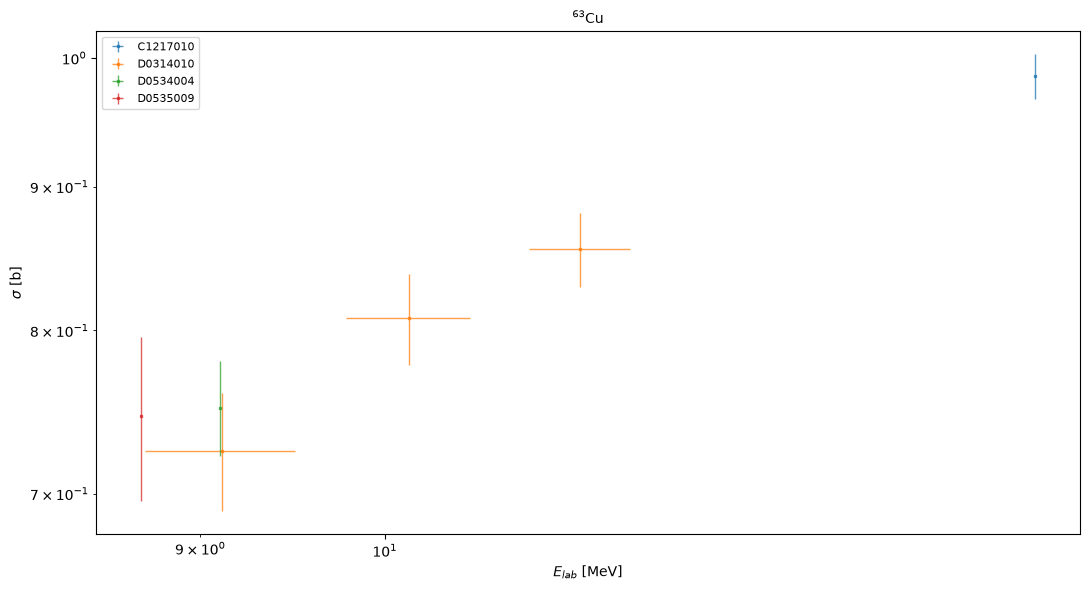

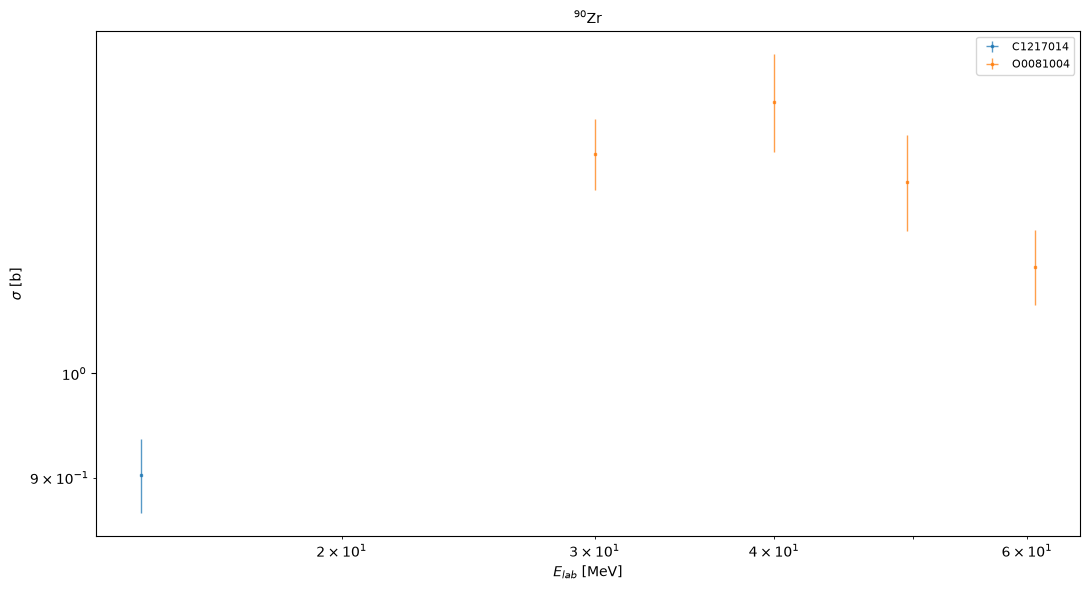

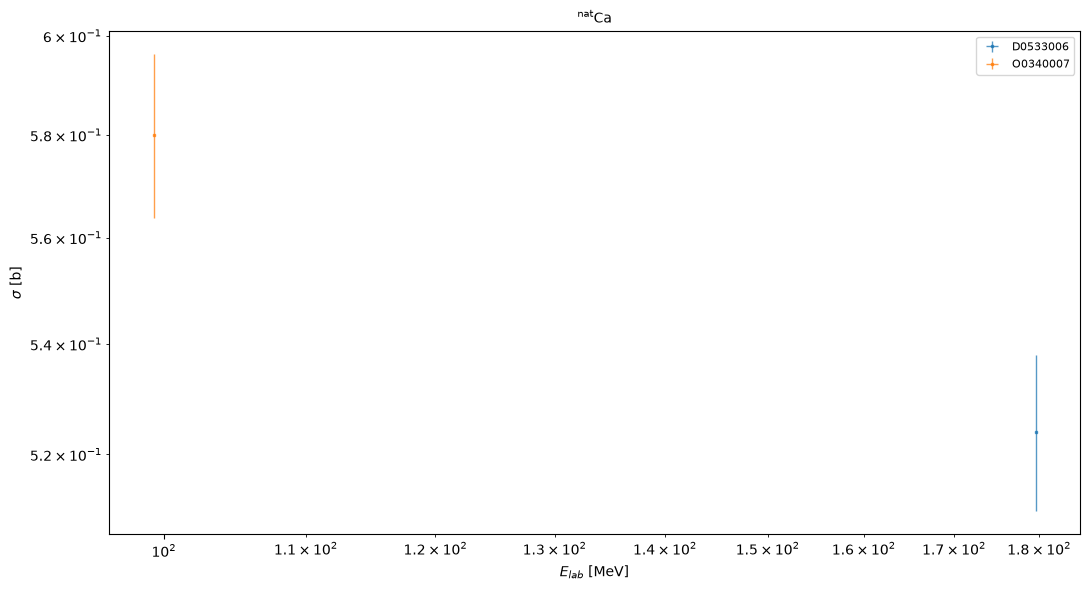

In [6]:
plotting.plot_sector(result, max_targets=8)
plt.show()

## Write

`corpus.write` re-checks coverage against the allowlist before writing, so a data set
that silently disappears from EXFOR fails here rather than passing unnoticed.

In [7]:
corpus.write(result)
print(f"wrote {len(result.records)} measurements to data/{result.corpus}/{result.sector}/")

wrote 62 measurements to data/kduq/proton_reaction/
